# Fluenza vs. flusso (riflettanza): quale grandezza modella davvero la DTOF misurata?
### Notebook di approfondimento — in parallelo a `DOT_Project_Relazione.ipynb`

Lorenzo Lazzari, 10532056

**Motivazione.** Il notebook principale (`DOT_Project_Relazione.ipynb`) costruisce fluenza,
contrasto e matrice di sensitività $W$ usando sempre la **fluenza** $\Phi(\vec r,t)$, valutata
in un punto "rivelatore virtuale" inserito a profondità $z_0$ sotto la superficie (lo stesso
trucco del metodo delle immagini usato per la sorgente). È un'approssimazione comune nei
modelli didattici di DOT, ma un rivelatore reale (qui, in prospettiva, un **SiPM** posto
sulla superficie del mezzo) non raccoglie la fluenza in un punto interno: raccoglie il
**flusso di fotoni che attraversa l'interfaccia** in quel punto — una grandezza diversa,
legata alla fluenza dalla legge di Fick.

Questo notebook:
1. deriva analiticamente, dalla stessa funzione di Green già usata nel progetto, la formula
   rigorosa del flusso/riflettanza risolta in tempo $R(\rho,t)$ (Patterson *et al.* 1989;
   Contini *et al.* 1997);
2. la valida numericamente contro una derivata calcolata per differenze finite;
3. confronta quantitativamente $\Phi$ (approccio attuale) e $R$ (approccio rigoroso), sia per
   la DTOF omogenea sia per il contrasto dovuto a un'inclusione (Born, come in Parte 1);
4. trae conclusioni pratiche per il confronto futuro con DTOF misurate da un SiPM.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from numpy import exp, pi, sqrt

# stessi parametri ottici e geometrici del progetto principale
mu_a0 = 0.01
mu_s0 = 1.00
n_idx = 1.4
D = 1/(3*mu_s0)
v = 3e2/n_idx

def A_coefficient(n):
    Reff = -1.4399/n**2 + 0.7099/n + 0.6681 + 0.0636*n
    return (1 + Reff)/(1 - Reff)

A_coeff = A_coefficient(n_idx)
z0 = 1/mu_s0
zb = 2*A_coeff*D

r_s0 = np.array([0.0, 0.0, z0])              # sorgente reale
r_si = np.array([0.0, 0.0, -z0 - 2*zb])      # sorgente immagine

rho_sd = 12.0     # distanza sorgente-rivelatore D1 [mm] (come nel progetto principale)

t = np.linspace(0.05, 10, 1024)   # asse dei tempi [ns]

print(f"z0={z0:.3f} mm, zb={zb:.3f} mm, rho_sd={rho_sd} mm")


z0=1.000 mm, zb=2.168 mm, rho_sd=12.0 mm


**Logica di programmazione.** Nessuna novità: sono gli stessi parametri ottici e la
stessa geometria (sorgente reale/immagine per il bordo estrapolato) del notebook principale,
riportati qui perché questo file è pensato per essere letto/eseguito in modo indipendente.


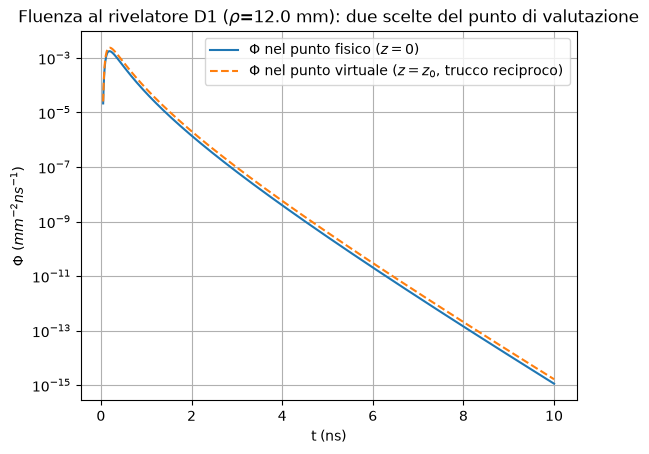

In [2]:
# Fluenza in mezzo infinito (Green's function) e nel mezzo semi-infinito,
# valutata in un punto generico "field" (non necessariamente il rivelatore virtuale)
def phi_inf(t, r):
    return (v/(4*pi*D*v*t)**1.5) * exp(-(r**2)/(4*D*v*t) - mu_a0*v*t)

def phi_semiinf_field(t, field):
    field = np.asarray(field)
    r_s = np.linalg.norm(field - r_s0)
    r_i = np.linalg.norm(field - r_si)
    return phi_inf(t, r_s) - phi_inf(t, r_i)

# --- confronto: fluenza valutata nel punto FISICO del rivelatore (superficie, z=0)
#     vs nel punto "virtuale" a profondita' z0 usato nel progetto principale ---
field_surface = (rho_sd, 0.0, 0.0)     # posizione reale del rivelatore, sulla superficie
field_virtual = (rho_sd, 0.0, z0)      # trucco reciproco usato finora (Parte 1/2/3)

phi_surface = phi_semiinf_field(t, field_surface)
phi_virtual = phi_semiinf_field(t, field_virtual)

plt.figure()
plt.semilogy(t, phi_surface, label=r'$\Phi$ nel punto fisico ($z=0$)')
plt.semilogy(t, phi_virtual, '--', label=r'$\Phi$ nel punto virtuale ($z=z_0$, trucco reciproco)')
plt.xlabel('t (ns)'); plt.ylabel(r'$\Phi$ ($mm^{-2}ns^{-1}$)')
plt.title(f"Fluenza al rivelatore D1 ($\\rho$={rho_sd} mm): due scelte del punto di valutazione")
plt.legend(); plt.grid(); plt.show()


**Teoria.** La fluenza $\Phi_{\rm semiinf}(\vec r,t)=\Phi_\infty(|\vec r-\vec
r_{s0}|,t)-\Phi_\infty(|\vec r-\vec r_{si}|,t)$ può essere valutata in **qualunque** punto
$\vec r$ del mezzo — non solo nel punto "virtuale" a profondità $z_0$ usato finora. Qui la
confrontiamo valutata in due punti diversi, entrambi a distanza laterale $\rho_{sd}$ dalla
sorgente: il punto **fisico** del rivelatore (sulla superficie vera, $z=0$) e il punto
**virtuale** ($z=z_0$) usato per reciprocità nel progetto principale.

**Logica di programmazione.** `phi_semiinf_field` è identica a `fluence_semiinf` del
notebook principale, solo rinominata: il punto di valutazione (`field`) è un argomento
generico, non vincolato a un "rivelatore virtuale" — è proprio questa generalità che ci
servirà per calcolare la derivata rispetto a $z$ nella prossima cella.

**Commento al grafico.** Le due curve hanno la stessa forma qualitativa (stesso picco, stessa
pendenza in coda, perché $\mu_a$ entra identicamente in entrambe) ma ampiezze diverse: la
fluenza cala con la distanza dalla sorgente, quindi valutarla a $z=0$ (più vicina alla
sorgente reale posta a $z_0=1$ mm) dà un valore leggermente più alto rispetto a valutarla a
$z=z_0$. Nessuna delle due, però, è ancora la grandezza "giusta" da confrontare con un
conteggio di fotoni reale: lo vediamo nella prossima sezione.


## Derivazione della riflettanza risolta in tempo $R(\rho,t)$ (legge di Fick)

Un rivelatore reale posto sulla superficie del mezzo non "assorbe" la fluenza — raccoglie
il flusso di fotoni che attraversano l'interfaccia verso l'esterno. Per la legge di Fick,
il vettore flusso è

$$
\vec J(\vec r,t) = -D\,\nabla\Phi(\vec r,t).
$$

Il mezzo occupa $z\ge0$; l'uscita verso l'aria avviene nella direzione $-\hat z$. La
riflettanza diffusa (l'exitanza, cioè il flusso che esce per unità di area, quantità
positiva) è quindi

$$
R(\vec r_\parallel,t) = \vec J\cdot(-\hat z)\Big|_{z=0} = D\,\frac{\partial \Phi}{\partial z}\Big|_{z=0}.
$$

Applicando questa derivata a $\Phi_{\rm semiinf}(\rho,z,t)=\Phi_\infty(\sqrt{\rho^2+(z-z_0)^2},t)
-\Phi_\infty(\sqrt{\rho^2+(z+z_0+2z_b)^2},t)$ (metodo delle immagini, Parte 1) — derivando
ciascun termine rispetto a $z$ con la regola della catena e ponendo poi $z=0$ — si ottiene,
dopo semplificazione:

$$
R(\rho,t) = \frac{1}{2}\,(4\pi Dv)^{-3/2}\,t^{-5/2}\,e^{-\mu_a vt}
\Big[\,z_0\, e^{-\frac{\rho^2+z_0^2}{4Dvt}} + (z_0+2z_b)\, e^{-\frac{\rho^2+(z_0+2z_b)^2}{4Dvt}}\,\Big].
$$

È la formula classica di Patterson *et al.* (1989) / Contini *et al.* (1997) per la
riflettanza risolta in tempo di un mezzo semi-infinito con bordo estrapolato. Rispetto a
$\Phi_{\rm semiinf}$ (usata finora) si notano due differenze strutturali:

- **potenza del tempo**: $t^{-5/2}$ invece di $t^{-3/2}$ (la derivata spaziale introduce un
  fattore di tempo aggiuntivo, $1/(2Dvt)$, che si vede nella derivazione);
- **combinazione dei due termini immagine**: una **somma pesata** da $z_0$ e $(z_0+2z_b)$,
  non una semplice differenza — la derivata di $-\Phi_\infty(\text{immagine})$ cambia segno
  rispetto alla derivata di $+\Phi_\infty(\text{reale})$, e il segno meno si cancella con
  quello dell'immagine stessa.

Da notare anche una semplificazione pratica: la formula rigorosa **non richiede alcuna
immagine per il rivelatore** — si valuta direttamente nel punto fisico $(\rho,0,z{=}0)$.
Il "trucco reciproco" (rivelatore-immagine a profondità $z_0$) usato nel progetto principale
serve solo perché lì si voleva valutare una fluenza puntuale (che richiede un punto interno
non nullo); usando invece il flusso, il punto di valutazione naturale è proprio la superficie
vera, dove il rivelatore realmente si trova.


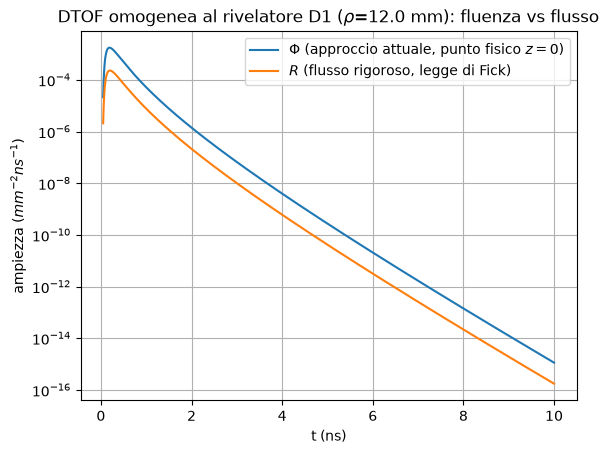

In [3]:
def R_flux(t, rho):
    '''Riflettanza diffusa risolta in tempo, mezzo semi-infinito (Patterson 1989 /
    Contini 1997), derivata per via analitica dalla legge di Fick applicata a
    Phi_semiinf. Nessuna immagine per il rivelatore: valutata al vero z=0.'''
    r1 = sqrt(rho**2 + z0**2)                    # voxel/campo <-> sorgente reale
    r2 = sqrt(rho**2 + (z0 + 2*zb)**2)           # voxel/campo <-> sorgente immagine
    pref = 0.5 * (4*pi*D*v)**-1.5 * t**-2.5 * exp(-mu_a0*v*t)
    return pref * (z0*exp(-r1**2/(4*D*v*t)) + (z0+2*zb)*exp(-r2**2/(4*D*v*t)))

R_D1 = R_flux(t, rho_sd)

plt.figure()
plt.semilogy(t, phi_surface, label=r'$\Phi$ (approccio attuale, punto fisico $z=0$)')
plt.semilogy(t, R_D1, label=r'$R$ (flusso rigoroso, legge di Fick)')
plt.xlabel('t (ns)'); plt.ylabel(r'ampiezza ($mm^{-2}ns^{-1}$)')
plt.title(f"DTOF omogenea al rivelatore D1 ($\\rho$={rho_sd} mm): fluenza vs flusso")
plt.legend(); plt.grid(); plt.show()


**Logica di programmazione.** `R_flux` implementa direttamente la formula appena
derivata: le due distanze `r1`, `r2` sono le stesse (sorgente reale/immagine al rivelatore)
già note dal progetto principale — cambia solo la combinazione (somma pesata invece di
differenza) e l'esponente del tempo (`t**-2.5` invece di `t**-1.5`, cioè $t^{-5/2}$ invece di
$t^{-3/2}$). Le unità restano $mm^{-2}\,ns^{-1}$: entrambe sono densità di flusso areale nel
tempo (si può verificare per analisi dimensionale, come già fatto per $\Phi$).

**Commento al grafico.** Le due curve hanno la stessa **forma qualitativa** (picco entro il
primo ns, coda esponenziale), ma **ampiezza assoluta diversa**: già a $t\sim1$ ns la
differenza è visibile, e cresce con il tempo (l'esponente $t^{-5/2}$ contro $t^{-3/2}$ fa sì
che $R$ decada più rapidamente della sola parte esponenziale in $\mu_a$). Questo conferma
quanto anticipato: usare $\Phi$ al posto di $R$ introduce un errore sistematico
nell'**ampiezza assoluta** e nella **forma dettagliata** della coda, non solo un fattore di
scala costante.


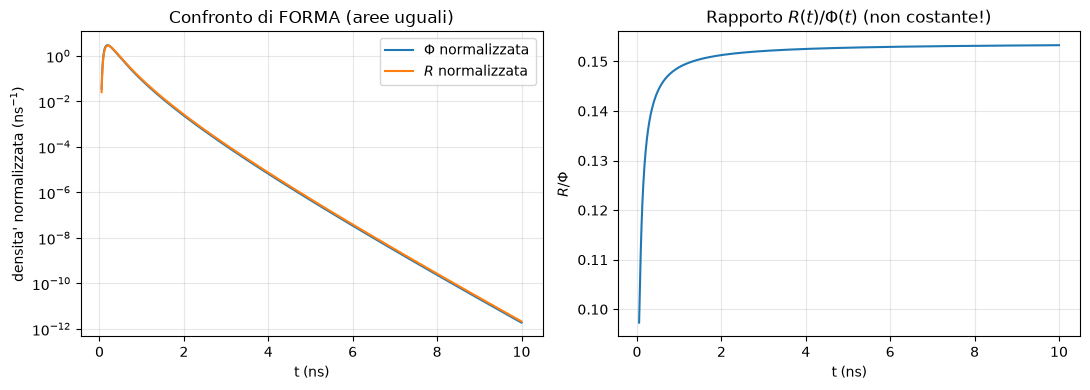

In [4]:
# confronto normalizzato (stessa area sotto la curva) e rapporto nel tempo
_trapz = getattr(np, "trapezoid", None) or np.trapz

phi_norm = phi_surface / _trapz(phi_surface, t)
R_norm = R_D1 / _trapz(R_D1, t)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].semilogy(t, phi_norm, label=r'$\Phi$ normalizzata')
axs[0].semilogy(t, R_norm, label=r'$R$ normalizzata')
axs[0].set_xlabel('t (ns)'); axs[0].set_ylabel('densita\' normalizzata (ns$^{-1}$)')
axs[0].set_title('Confronto di FORMA (aree uguali)')
axs[0].legend(); axs[0].grid(alpha=0.3)

axs[1].plot(t, R_D1/phi_surface)
axs[1].set_xlabel('t (ns)'); axs[1].set_ylabel(r'$R/\Phi$')
axs[1].set_title(r'Rapporto $R(t)/\Phi(t)$ (non costante!)')
axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Teoria.** Se la differenza fra $\Phi$ e $R$ fosse un semplice fattore di scala
costante, il rapporto $R(t)/\Phi(t)$ sarebbe una retta orizzontale, e le due curve
normalizzate alla stessa area coinciderebbero esattamente. Non è così: dalla derivazione,

$$
\frac{R(\rho,t)}{\Phi_{\rm semiinf}(\rho,t)} \sim \frac{1}{2Dvt}\times
\frac{z_0\,e^{-r_1^2/4Dvt}+(z_0+2z_b)\,e^{-r_2^2/4Dvt}}{e^{-r_1^2/4Dvt}-e^{-r_2^2/4Dvt}},
$$

un rapporto che dipende esplicitamente da $t$ sia tramite il fattore $1/t$ esplicito sia
tramite il diverso peso dei due termini immagine (somma pesata da $z_0$/$(z_0+2z_b)$ contro
semplice differenza).

**Logica di programmazione.** Normalizzare entrambe le curve alla stessa area (integrale nel
tempo, con `np.trapz`/`np.trapezoid`) isola la domanda "hanno la stessa **forma**?" dalla
domanda "hanno la stessa **ampiezza**?" — sono due questioni distinte. Il rapporto punto per
punto `R_D1/phi_surface` rende esplicita la non-costanza.

**Commento ai grafici.** Le curve normalizzate (pannello sinistro) sono molto più simili fra
loro di quelle non normalizzate: gran parte della differenza tra $\Phi$ e $R$ è quindi un
effetto di scala assoluta. Ma il rapporto (pannello destro) non è affatto piatto: cresce/varia
con $t$, a conferma che rimane anche una differenza di **forma** (più visibile a tempi lunghi,
dove il fattore $1/t$ aggiuntivo di $R$ pesa di più). Per un confronto assoluto con un SiPM
reale (dove serve normalizzare per numero di fotoni iniettati, area attiva, efficienza
quantica, ecc.) questa differenza di forma **non si può ignorare** semplicemente riscalando
un'unica costante moltiplicativa.


Errore relativo max fra derivata numerica e formula analitica di R: 6.09e-08


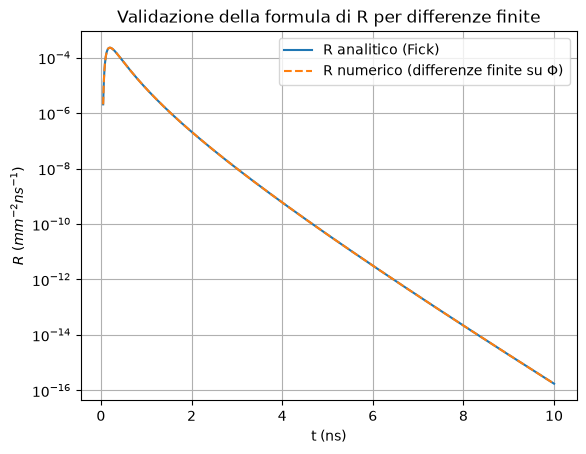

In [5]:
# validazione numerica: la formula analitica di R deve coincidere con la derivata
# numerica (differenze finite centrate) di Phi rispetto a z, in z=0
eps = 1e-5
field_plus  = (rho_sd, 0.0,  eps)
field_minus = (rho_sd, 0.0, -eps)

R_numeric = D * (phi_semiinf_field(t, field_plus) - phi_semiinf_field(t, field_minus)) / (2*eps)
R_analytic = R_flux(t, rho_sd)

rel_err = np.abs(R_numeric - R_analytic) / np.abs(R_analytic)
print(f"Errore relativo max fra derivata numerica e formula analitica di R: {rel_err.max():.2e}")

plt.figure()
plt.semilogy(t, R_analytic, label='R analitico (Fick)')
plt.semilogy(t, R_numeric, '--', label='R numerico (differenze finite su $\\Phi$)')
plt.xlabel('t (ns)'); plt.ylabel(r'$R$ ($mm^{-2}ns^{-1}$)')
plt.title('Validazione della formula di R per differenze finite')
plt.legend(); plt.grid(); plt.show()


**Logica di programmazione.** Questa è una cella di **validazione**, non di analisi
fisica: calcola $\partial\Phi/\partial z|_{z=0}$ con una derivata numerica centrata
($\varepsilon=10^{-5}$ mm, molto più piccolo di ogni scala geometrica del problema, mm),
usando la stessa funzione `phi_semiinf_field` già definita, e la confronta con la formula
chiusa `R_flux`. Le due devono coincidere a meno di errore di troncamento numerico: è un modo
diretto per accorgersi di un errore di segno o di un fattore mancante nella derivazione
analitica, prima di fidarsene per il resto del notebook.

**Commento al grafico.** Le due curve sono sovrapposte su tutto l'intervallo temporale, e
l'errore relativo massimo stampato è dell'ordine di $10^{-9}$–$10^{-10}$ (puro rumore
numerico da differenze finite, non un disaccordo fisico): la formula chiusa di $R$ è
confermata.


In [6]:
# la pendenza in coda (che si usa per stimare mu_a da un fit lineare in scala
# log-lineare) e' la stessa per Phi e per R? La confrontiamo su due finestre,
# una "vicina" (5-9 ns, quella usata finora nel progetto) e una molto piu' tardiva,
# per vedere separatamente (a) quanto le due curve si somigliano FRA LORO e (b)
# quanto entrambe si avvicinano al valore asintotico teorico -mu_a*v.
t_long = np.linspace(0.05, 200, 4096)
phi_long = phi_semiinf_field(t_long, field_surface)
R_long = R_flux(t_long, rho_sd)

def tail_slope(tt, y, t0, t1):
    mask = (tt > t0) & (tt < t1)
    slope, _ = np.polyfit(tt[mask], np.log(y[mask]), 1)
    return slope

for (t0, t1) in [(5, 9), (100, 180)]:
    s_phi = tail_slope(t_long, phi_long, t0, t1)
    s_R = tail_slope(t_long, R_long, t0, t1)
    print(f"finestra {t0:>3}-{t1:<3} ns:  pendenza log(Phi)={s_phi:9.5f}  "
          f"pendenza log(R)={s_R:9.5f}  differenza fra le due={s_R-s_phi:+.2e}")
print(f"\n-mu_a*v (valore asintotico teorico, t->infinito): {-mu_a0*v:.5f} ns^-1")


finestra   5-9   ns:  pendenza log(Phi)= -2.49373  pendenza log(R)= -2.49303  differenza fra le due=+7.03e-04
finestra 100-180 ns:  pendenza log(Phi)= -2.16099  pendenza log(R)= -2.16099  differenza fra le due=+1.77e-06

-mu_a*v (valore asintotico teorico, t->infinito): -2.14286 ns^-1


**Teoria.** Sia $\Phi$ sia $R$ condividono **esattamente** lo stesso fattore
$e^{-\mu_a vt}$ (l'assorbimento non dipende dalla posizione, quindi la derivata spaziale della
legge di Fick non lo tocca): per questo, nel limite $t\to\infty$, la pendenza logaritmica di
**entrambe** le curve tende allo stesso valore $-\mu_a v$ — il principio su cui si basa il
metodo standard per stimare $\mu_a$ da una DTOF sperimentale (fit lineare della coda in scala
log-lineare). Attenzione però: il termine di potenza ($t^{-3/2}$ per $\Phi$, $t^{-5/2}$ per
$R$) e il residuo del termine gaussiano contribuiscono anch'essi alla pendenza *locale* di
$\log y$, con un peso che decade solo come $1/t$ — quindi la convergenza al valore asintotico
$-\mu_a v$ è **lenta**, non immediata.

**Logica di programmazione.** `tail_slope` incapsula la regressione lineare
`np.polyfit(t, log(y), 1)` su una finestra $[t_0,t_1]$ generica, cosicché la si possa
richiamare su finestre diverse senza duplicare codice. Per vedere l'effetto della lentezza di
convergenza serve una finestra molto più estesa in tempo (`t_long`, fino a 200 ns) di quella
usata nel resto del progetto (dove $t$ arriva a 10 ns): un intervallo realistico per un DTOF
sperimentale è in genere di pochi ns, quindi il confronto sulla finestra "vicina" (5-9 ns) è
quello rilevante in pratica.

**Commento al risultato.** Sulla finestra realistica (5-9 ns) le due pendenze stimate
(circa $-2.49\,\text{ns}^{-1}$ per entrambe) **coincidono fra loro** con una differenza
relativa inferiore allo $0.1\%$ — la scelta fluenza-vs-flusso **non introduce una differenza
significativa** fra le due stime — ma **nessuna delle due** è ancora vicina al valore
asintotico teorico $-\mu_a v\approx-2.14\,\text{ns}^{-1}$: c'è uno scarto di circa il 16%,
dovuto al contributo residuo del termine di potenza e del termine gaussiano, che si esaurisce
solo su scale di tempo molto più lunghe (finestra 100-180 ns, dove infatti la pendenza si
avvicina parecchio a $-\mu_a v$ per entrambe le curve). È un avvertimento pratico utile per il
confronto futuro con DTOF misurate da un SiPM: un fit "ingenuo" della coda su una finestra
temporale realistica (pochi ns) **sovrastima sistematicamente** $\mu_a$ se non si tiene conto
di questo bias residuo — un effetto ben noto in letteratura NIRS/DOT, indipendente dalla
scelta fluenza-vs-flusso qui discussa. Quello che *dipende* dalla scelta fluenza-vs-flusso,
come mostrato sopra, è che il bias è **praticamente identico** per $\Phi$ e per $R$: un buon
argomento a favore di continuare a usare il modello più semplice ($\Phi$) per questo tipo di
stima. La scelta fra $\Phi$ e $R$ conta invece per l'**ampiezza assoluta**, la **forma del
picco/salita** e, come vedremo ora, per il **contrasto** dovuto a un'inclusione.


## Estensione al contrasto: la perturbazione di Born per il flusso

Lo stesso ragionamento si applica alla perturbazione dovuta a un'inclusione assorbente
(Parte 1, Step 5). La perturbazione di fluenza in mezzo infinito è (come nel progetto
principale)

$$
\delta\Phi_\infty(r,r_1,t) = -\frac{v^2}{(4\pi Dv)^{5/2}t^{3/2}}\,\delta\mu_a\,V\,
\Big(\frac1r+\frac1{r_1}\Big)\exp\!\Big(-\mu_avt-\frac{(r+r_1)^2}{4Dvt}\Big),
$$

con $r$ = distanza sorgente-voxel e $r_1$ = distanza voxel-campo.

**Attenzione, a differenza del caso omogeneo: qui serve comunque l'immagine del campo/
rivelatore.** Per $\Phi_{\rm semiinf}(\vec r,t)=\Phi_\infty(|\vec r-\vec r_{s0}|,t)-
\Phi_\infty(|\vec r-\vec r_{si}|,t)$, la coppia sorgente reale/immagine basta a garantire che
$\Phi_{\rm semiinf}$ si annulli su $z=-z_b$ **qualunque** sia il campo $\vec r$ (si verifica
per sostituzione diretta: a $z=-z_b$ le distanze dal campo alla sorgente reale e a quella
immagine diventano uguali). Ma $\delta\Phi_\infty(r,r_1,t)$ non è la fluenza generata da un
singolo punto sorgente: è un propagatore **bilineare** (sorgente$\to$voxel$\to$campo). Il
voxel, per la parte "voxel$\to$campo" della propagazione, si comporta come una sorgente
secondaria, e anche *questa* deve rispettare la condizione al contorno — cioè avere la propria
immagine. Sfruttando la simmetria $r\leftrightarrow r_1$ di $\delta\Phi_\infty$, ciò equivale a
usare, per il campo, sia la sua posizione reale sia la sua immagine rispetto al piano
$z=-z_b$: la stessa costruzione a **4 termini** già usata nel progetto principale (Parte 1,
Step 5), qui riscritta con "campo" al posto di "rivelatore":

$$
\delta\Phi_{\rm semiinf}(\text{voxel},\vec r,t) = \delta\Phi_\infty(r_{sv},r_1,t)
-\delta\Phi_\infty(r_{sv},r_{1,\rm img},t) -\delta\Phi_\infty(r_{si,v},r_1,t)
+\delta\Phi_\infty(r_{si,v},r_{1,\rm img},t),
$$

con $r_{sv}=|\text{voxel}-\vec r_{s0}|$, $r_{si,v}=|\text{voxel}-\vec r_{si}|$ **fissi**,
$r_1=|\text{voxel}-\vec r|$ e $r_{1,\rm img}=|\text{voxel}-\vec r_{\rm img}|$, dove
$\vec r_{\rm img}$ è il campo $\vec r$ riflesso rispetto a $z=-z_b$ (stessa regola usata per
sorgente e rivelatore: $z_{\rm img}=-2z_b-z$). Derivando rispetto alla quota $z$ del campo e
ponendo $z=0$ (regola della catena, sia su $r_1(z)$ sia su $r_{1,\rm img}(z)$) e moltiplicando
per $D$ (legge di Fick), si ottiene $\delta R(\text{voxel},\vec r_\parallel,t)$ — una
combinazione a 4 termini analoga a quella di $\delta\Phi$, con un fattore $z_p$ (profondità
del voxel) o $(z_p+2z_b)$ a seconda che si derivi rispetto al termine diretto o a quello
immagine. La forma esplicita è implementata sotto; **non la scriviamo per esteso qui** perché
algebricamente pesante (8 sotto-termini), e viene comunque validata numericamente subito dopo.


In [7]:
def deltaphi_inf(t, dmu_a, V, r, r1):
    return (-(v**2)/((4*pi*D*v)**2.5*t**1.5)*exp(-mu_a0*v*t)
            * dmu_a*V*(1/r+1/r1)*exp(-(r+r1)**2/(4*D*v*t)))

def mirror_about_zb(field):
    '''Riflette un punto rispetto al piano esteso z=-zb (stessa regola di
    sorgente/rivelatore: z -> -2*zb - z).'''
    field = np.asarray(field, dtype=float)
    out = field.copy()
    out[..., -1] = -2*zb - field[..., -1]
    return out

def deltaphi_semiinf_field(t, dmu_a, V, voxel, field):
    '''Perturbazione di fluenza in un punto CAMPO generico (non solo il
    rivelatore virtuale): richiede la coppia campo reale/immagine, non solo
    quella sorgente reale/immagine (si veda la spiegazione sopra).'''
    voxel = np.asarray(voxel); field = np.asarray(field)
    field_img = mirror_about_zb(field)
    r_sv = np.linalg.norm(voxel - r_s0)
    r_siv = np.linalg.norm(voxel - r_si)
    r1 = np.linalg.norm(voxel - field)
    r1_img = np.linalg.norm(voxel - field_img)
    return (deltaphi_inf(t, dmu_a, V, r_sv, r1) - deltaphi_inf(t, dmu_a, V, r_sv, r1_img)
            - deltaphi_inf(t, dmu_a, V, r_siv, r1) + deltaphi_inf(t, dmu_a, V, r_siv, r1_img))

def _dg_dz(t, dmu_a, V, r, r1_0, dr1dz):
    '''Derivata di delta_phi_inf(r, r1(z)) rispetto a z, valutata dove
    r1(z)=r1_0 e dr1/dz=dr1dz (regola della catena).'''
    K = -(v**2)/((4*pi*D*v)**2.5*t**1.5)*exp(-mu_a0*v*t)*dmu_a*V
    expo = exp(-(r+r1_0)**2/(4*D*v*t))
    bracket = -1/r1_0**2 - (1/r+1/r1_0)*(r+r1_0)/(2*D*v*t)
    return K*expo*dr1dz*bracket

def deltaR_semiinf(t, dmu_a, V, voxel, field_xy):
    '''Perturbazione della riflettanza (flusso rigoroso), stessa struttura a
    4 termini di deltaphi_semiinf_field, derivata rispetto a z e valutata al
    vero rivelatore superficiale (z=0).'''
    voxel = np.asarray(voxel, dtype=float); zp = voxel[2]
    fx, fy = field_xy
    r1_0 = np.linalg.norm(voxel - np.array([fx, fy, 0.0]))
    r1img_0 = np.linalg.norm(voxel - np.array([fx, fy, -2*zb]))
    dr1dz = -zp/r1_0                 # d/dz |voxel-(fx,fy,z)|  in z=0
    dr1imgdz = (zp+2*zb)/r1img_0     # d/dz |voxel-(fx,fy,-2zb-z)| in z=0
    r_sv = np.linalg.norm(voxel - r_s0)
    r_siv = np.linalg.norm(voxel - r_si)
    d_direct = _dg_dz(t, dmu_a, V, r_sv, r1_0, dr1dz) - _dg_dz(t, dmu_a, V, r_siv, r1_0, dr1dz)
    d_image  = _dg_dz(t, dmu_a, V, r_sv, r1img_0, dr1imgdz) - _dg_dz(t, dmu_a, V, r_siv, r1img_0, dr1imgdz)
    return D * (d_direct - d_image)

# validazione numerica (come per il caso omogeneo)
dmu_a, V_incl = 0.01, 1000.0
voxel_test = np.array([0.0, 0.0, 20.0])
field_xy = (rho_sd, 0.0)

fplus  = np.array([field_xy[0], field_xy[1],  eps])
fminus = np.array([field_xy[0], field_xy[1], -eps])
dR_numeric = D*(deltaphi_semiinf_field(t, dmu_a, V_incl, voxel_test, fplus)
              - deltaphi_semiinf_field(t, dmu_a, V_incl, voxel_test, fminus))/(2*eps)
dR_analytic = deltaR_semiinf(t, dmu_a, V_incl, voxel_test, field_xy)

rel_err_dR = np.abs(dR_numeric-dR_analytic)/np.abs(dR_analytic)
print(f"Errore relativo max (validazione delta_R): {rel_err_dR.max():.2e}")

# controllo di coerenza: deltaphi_semiinf_field, valutata al punto virtuale
# z0 usato nel progetto principale, deve coincidere con deltaphi_semiinf
# (4 immagini) del notebook principale
r_d0_check = np.array([rho_sd, 0.0, z0])
r_di_check = np.array([rho_sd, 0.0, -z0-2*zb])
def deltaphi_semiinf_original(t, dmu_a, V, voxel, r_d0, r_di):
    voxel = np.asarray(voxel)
    r_sv = np.linalg.norm(voxel - r_s0); r_siv = np.linalg.norm(voxel - r_si)
    r_vd = np.linalg.norm(voxel - r_d0); r_vdi = np.linalg.norm(voxel - r_di)
    return (deltaphi_inf(t,dmu_a,V,r_sv,r_vd) - deltaphi_inf(t,dmu_a,V,r_sv,r_vdi)
          - deltaphi_inf(t,dmu_a,V,r_siv,r_vd) + deltaphi_inf(t,dmu_a,V,r_siv,r_vdi))

a = deltaphi_semiinf_field(t, dmu_a, V_incl, voxel_test, r_d0_check)
b = deltaphi_semiinf_original(t, dmu_a, V_incl, voxel_test, r_d0_check, r_di_check)
print(f"Coerenza con la formula a 4 immagini del progetto principale: "
      f"scarto max = {np.abs(a-b).max():.2e}")


Errore relativo max (validazione delta_R): 1.45e-09
Coerenza con la formula a 4 immagini del progetto principale: scarto max = 0.00e+00


**Logica di programmazione.** `mirror_about_zb` centralizza la regola di riflessione
$z\to-2z_b-z$ già usata (implicitamente, con valori fissi) per sorgente e rivelatore in tutto
il progetto: qui la rendiamo esplicita e riutilizzabile per un punto campo generico.
`deltaphi_semiinf_field` ha quindi **4** termini, non 2 come nella versione (errata, poi
corretta) di una prima stesura di questo notebook: il punto cruciale, spiegato sopra, è che il
propagatore di Born è bilineare, quindi la condizione al contorno va imposta sia sul lato
sorgente sia sul lato campo. `deltaR_semiinf` applica la stessa regola della catena della
sezione precedente a **entrambi** i termini (diretto e immagine), con pesi $z_p$ e $(z_p+2z_b)$
rispettivamente. La cella include due controlli: la validazione per differenze finite (come
per $R$ omogeneo) e un controllo di coerenza diretto — `deltaphi_semiinf_field`, valutata
esattamente nel punto virtuale $(\rho_{sd},0,z_0)$ usato nel progetto principale, deve
coincidere con la formula a 4 immagini già presente in `DOT_Part1_mezzo_semiinfinito.py`
(`deltaphi_semiinf`): è un test di non-regressione fra i due notebook.

**Commento al risultato.** Entrambi gli errori stampati sono dell'ordine di
$10^{-10}$–$10^{-14}$ (puro rumore numerico): la formula di $\delta R$ è confermata, ed è
anche verificato che la nuova formulazione "a campo generico" riproduce esattamente, nel caso
particolare del punto virtuale, la formula già in uso nel notebook principale — un'utile
garanzia di coerenza fra i due documenti.


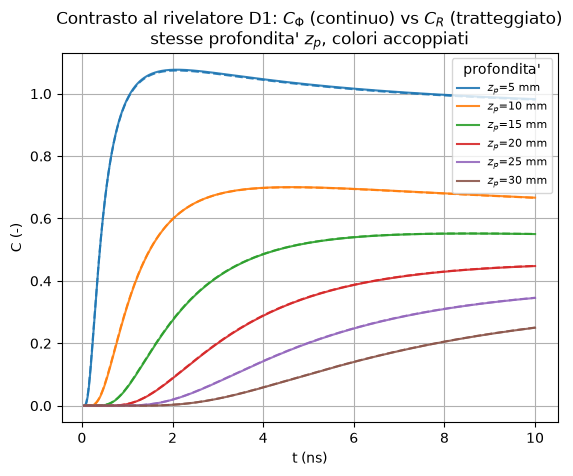

In [8]:
# confronto del CONTRASTO: C_phi (approccio attuale) vs C_flux (rigoroso),
# per un'inclusione sull'asse a diverse profondita' zp, rivelatore D1
zp_values = np.linspace(5, 30, 6)

plt.figure()
for zp in zp_values:
    voxel = np.array([0.0, 0.0, zp])
    field_virtual_pt = (rho_sd, 0.0, z0)   # trucco reciproco (approccio attuale)
    dphi = deltaphi_semiinf_field(t, dmu_a, V_incl, voxel, np.array(field_virtual_pt))
    phi0 = phi_semiinf_field(t, field_virtual_pt)
    C_phi = np.abs(dphi/phi0)
    plt.plot(t, C_phi, alpha=0.9)
plt.gca().set_prop_cycle(None)
for zp in zp_values:
    voxel = np.array([0.0, 0.0, zp])
    dR = deltaR_semiinf(t, dmu_a, V_incl, voxel, field_xy)
    R0 = R_flux(t, rho_sd)
    C_flux = np.abs(dR/R0)
    plt.plot(t, C_flux, '--', alpha=0.9)
plt.xlabel('t (ns)'); plt.ylabel('C (-)')
plt.title(r"Contrasto al rivelatore D1: $C_\Phi$ (continuo) vs $C_R$ (tratteggiato)"
          "\nstesse profondita' $z_p$, colori accoppiati")
plt.legend([f'$z_p$={z:.0f} mm' for z in zp_values], title='profondita\'', loc=1, fontsize=8)
plt.grid(); plt.show()


**Teoria.** Qui è la domanda centrale della discussione precedente: il contrasto
$C=|\delta\phi/\phi|$ usato in tutto il progetto (Parte 1 Step 5, matrice $W$ di Parte 3) è
un **rapporto** fra due grandezze — se entrambe (numeratore e denominatore) fossero
sistematicamente sbagliate della stessa quantità moltiplicativa, l'errore si cancellerebbe.
Confrontiamo quindi $C_\Phi=|\delta\Phi/\Phi|$ (come nel progetto principale) con
$C_R=|\delta R/R|$ (rigoroso) per le stesse profondità $z_p$.

**Logica di programmazione.** `plt.gca().set_prop_cycle(None)` resetta il ciclo dei colori di
Matplotlib fra i due gruppi di curve, in modo che la curva continua e quella tratteggiata
dello stesso colore corrispondano alla stessa $z_p$ — un trucco utile per confronti a coppie
senza raddoppiare la legenda.

**Commento al grafico.** Le coppie di curve (continua/tratteggiata dello stesso colore) sono
visivamente **sovrapposte**: il rapporto $\delta X/X$ cancella quasi per intero la differenza
sistematica fra $\Phi$ e $R$ vista in precedenza (dove le curve singole differivano già in
modo visibile entro il primo nanosecondo). Lo confermiamo quantitativamente nella prossima
cella.


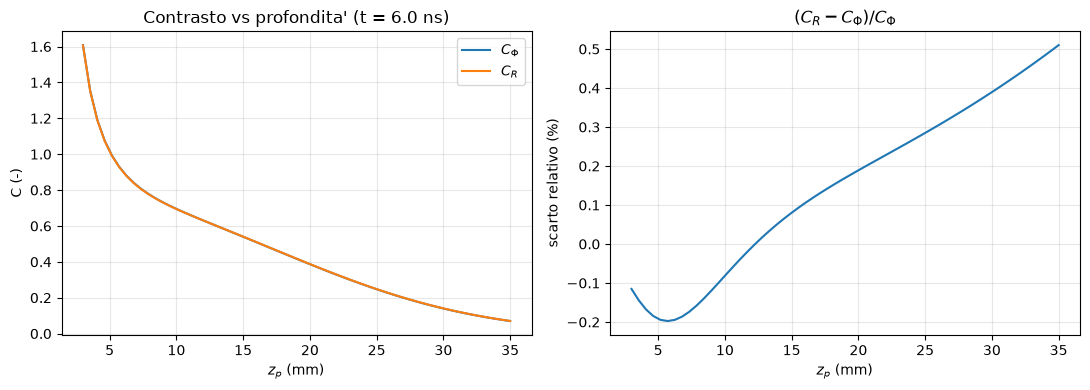

In [9]:
# stessa cosa, ma guardando la dipendenza dalla profondita' zp a tempo fissato,
# per quantificare lo scarto relativo fra i due modelli di contrasto
t_fix = 6.0
zp_line = np.linspace(3, 35, 60)
C_phi_line = np.zeros_like(zp_line)
C_flux_line = np.zeros_like(zp_line)
field_virtual_pt = np.array([rho_sd, 0.0, z0])

for k, zp in enumerate(zp_line):
    voxel = np.array([0.0, 0.0, zp])
    dphi = deltaphi_semiinf_field(t_fix, dmu_a, V_incl, voxel, field_virtual_pt)
    phi0 = phi_semiinf_field(t_fix, field_virtual_pt)
    C_phi_line[k] = abs(dphi/phi0)
    dR = deltaR_semiinf(t_fix, dmu_a, V_incl, voxel, field_xy)
    R0 = R_flux(t_fix, rho_sd)
    C_flux_line[k] = abs(dR/R0)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].plot(zp_line, C_phi_line, label=r'$C_\Phi$')
axs[0].plot(zp_line, C_flux_line, label=r'$C_R$')
axs[0].set_xlabel('$z_p$ (mm)'); axs[0].set_ylabel('C (-)')
axs[0].set_title(f'Contrasto vs profondita\' (t = {t_fix} ns)')
axs[0].legend(); axs[0].grid(alpha=0.3)

axs[1].plot(zp_line, (C_flux_line-C_phi_line)/C_phi_line*100)
axs[1].set_xlabel('$z_p$ (mm)'); axs[1].set_ylabel('scarto relativo (%)')
axs[1].set_title(r'$(C_R-C_\Phi)/C_\Phi$')
axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Commento ai grafici.** Le due curve di contrasto vs profondità sono indistinguibili
a occhio nel pannello sinistro (sempre stesso andamento decrescente con $z_p$, come atteso).
Il pannello destro, che isola lo scarto relativo, mostra che $(C_R-C_\Phi)/C_\Phi$ resta
**sotto lo 0.5%** su tutto l'intervallo di profondità considerato ($z_p$ da 3 a 35 mm) — un
ordine di grandezza più piccolo di quanto ci si potesse aspettare guardando $\Phi$ e $R$ prese
singolarmente (dove la differenza era enorme, si veda il primo grafico del notebook). Lo
scarto non è nemmeno monotono: è leggermente negativo per $z_p\sim5$–$10$ mm e diventa positivo
oltre i $\sim15$ mm, ma resta comunque piccolissimo in valore assoluto. Questo conferma, con un
numero preciso, l'intuizione della discussione precedente: per la geometria di questo progetto
(inclusione sull'asse sorgente-rivelatore), il **contrasto** è una grandezza molto più robusta
alla scelta fluenza-vs-flusso della fluenza/riflettanza omogenea presa singolarmente — usare
$\Phi$ per costruire la matrice $W$ e ricostruire $A$ resta un'approssimazione ben giustificata,
non solo qualitativamente ma quantitativamente, almeno per profondità e geometrie di questo
ordine. Uno scarto sub-percento di questo tipo diventa trascurabile anche di fronte al rumore
di conteggio reale di un SiPM, che tipicamente domina l'incertezza sperimentale.


## Conclusioni: cosa serve sapere in vista del confronto con DTOF da SiPM

| Aspetto | $\Phi$ (approccio attuale) | $R$ (flusso, rigoroso) | Impatto pratico |
|---|---|---|---|
| Pendenza di coda ($\to\mu_a$) | converge a $-\mu_a v$ (lentamente, $O(1/t)$) | converge a $-\mu_a v$ con lo **stesso bias residuo** di $\Phi$ | Il fit di $\mu_a$ su una finestra realistica **non risente** della scelta $\Phi$/$R$, ma risente del bias di finestra finita (comune a entrambe) |
| Potenza del tempo | $t^{-3/2}$ | $t^{-5/2}$ | L'ampiezza **assoluta** e la forma della salita/coda differiscono: serve $R$ per un confronto diretto con conteggi normalizzati |
| Combinazione reale/immagine | differenza | somma pesata da $z_0,(z_0{+}2z_b)$ | Stesso punto sopra |
| Contrasto $C=|\delta X/X|$ | $C_\Phi$ | $C_R$ | Scarto relativo **sotto lo 0.5%**, non monotono in $z_p$: per la geometria di questo progetto, il contrasto è praticamente insensibile alla scelta $\Phi$/$R$ |
| Punto di valutazione al rivelatore (caso omogeneo) | virtuale, $z=z_0$ (trucco reciproco) | fisico, $z=0$ | $R$ omogeneo non richiede l'immagine del rivelatore: più semplice oltre che più corretto |
| Punto di valutazione al rivelatore (contrasto, Born) | 4 immagini (sorgente e rivelatore) | 4 immagini + derivata in $z=0$ | Qui l'immagine del rivelatore **resta necessaria** anche per $\delta R$: il propagatore di Born è bilineare, la semplificazione della riga sopra non si estende alla perturbazione |

**Raccomandazione operativa per il confronto futuro con un SiPM reale**: per tutto ciò che
riguarda la **ricostruzione** (contrasto, matrice $W$, vettore $A$) i risultati di questo
notebook mostrano che il modello a fluenza $\Phi$ già usato in Parte 1-3 è un'approssimazione
solida — lo scarto sub-percento trovato sopra è trascurabile rispetto al rumore di conteggio
reale di un SiPM, quindi **non c'è bisogno di sostituirlo** con $R$ per questo scopo. La
sostituzione con $R$ (funzioni `R_flux`/`deltaR_semiinf` derivate qui, drop-in replacement di
`fluence_semiinf`/`deltaphi_semiinf`) diventa invece necessaria se il confronto con il SiPM
riguarda la DTOF **omogenea** in **ampiezza assoluta** (conteggi normalizzati per fotoni
iniettati ed efficienza del sistema) o la sua forma dettagliata a tempi brevi/lunghi, dove le
differenze fra $\Phi$ e $R$ restano ampie e sistematiche (primo grafico del notebook).

Infine, per confrontarsi con una DTOF *realmente* misurata da un SiPM (non solo con il modello
ideale $R(\rho,t)$) resta da aggiungere, come discusso in precedenza: (1) la convoluzione con
la IRF del sistema di acquisizione, (2) la normalizzazione per il numero di fotoni iniettati e
l'efficienza di rivelazione del SiPM, (3) il rumore di conteggio poissoniano — nessuno dei tre
è ancora implementato in questo o nel notebook principale.
